In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

print("Libraries berhasil dimuat!")

Libraries berhasil dimuat!


In [4]:
file_path = 'DATA.xlsx'
df_raw = pd.read_excel(file_path)

print(f"File    : {file_path}")
print(f"Baris   : {len(df_raw)}")
print(f"Kolom   : {len(df_raw.columns)}")
print(f"\nDaftar Kolom:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

File    : DATA.xlsx
Baris   : 1780
Kolom   : 24

Daftar Kolom:
   1. ID
   2. Nama Chemical
   3. Nama
   4. Tanggal
   5. Jam Masuk
   6. Batch
   7. Deskripsi
   8. Status
   9. Transmission
  10. APE
  11. Tinx
  12. RI
  13. SG
  14. Acid
  15. Sulfur
  16. Water
  17. Mono
  18. Yellow
  19. EH
  20. Visco
  21. PT
  22. Created At
  23. Updated At
  24. Orang


In [5]:
print("5 Baris Pertama:")
df_raw.head()

5 Baris Pertama:


,ID,Nama Chemical,Nama,Tanggal,Jam Masuk,Batch,Deskripsi,Status,Transmission,APE,...,Sulfur,Water,Mono,Yellow,EH,Visco,PT,Created At,Updated At,Orang
0,11,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:21,TG2024L28,ANALISIS ALL PARAMETER,Approve,99.275,Clear,...,12.081,3.48,-,7.84,0.0001,47.2,10,2025-05-07T08:34:05.000000Z,2025-05-15T13:02:21.000000Z,Nikmatullah
1,12,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:43,TG2025A07,ANALISIS ALL PARAMETER,Approve,99.229,Clear,...,11.926,3.48,-,7.9,0.0005,45.07,10,2025-05-07T08:34:30.000000Z,2025-05-15T13:02:43.000000Z,Nikmatullah
2,13,Tinstab,MT-620,2025-05-07,2025-05-15 20:02:44,TG2025B07-1,ANALISIS ALL PARAMETER,Approve,99.286,Clear,...,11.849,3.48,-,7.79,0.0001,49.4,10,2025-05-07T08:34:50.000000Z,2025-05-15T13:02:44.000000Z,Nikmatullah
3,38,Tinstab,MT-620,2025-05-09,2025-05-20 00:44:11,TG02025E05,Awal tengah akhir,Approve,99.216,Clear,...,12.099,3.49,NaN,7.85,NaN,49.6,10,2025-05-09T09:46:10.000000Z,2025-05-19T17:44:11.000000Z,Anto S
4,39,Tinstab,MT-620,2025-05-09,2025-05-19 23:56:22,TG02025E06,Awal tengah akhir,Approve,99.308,Clear,...,12.176,3.49,NaN,7.82,NaN,47.2,10,2025-05-09T09:46:53.000000Z,2025-05-19T16:56:22.000000Z,Anto S


In [6]:
print("Informasi Dataset:")
df_raw.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1780 non-null   int64 
 1   Nama Chemical  1780 non-null   object
 2   Nama           1780 non-null   object
 3   Tanggal        1780 non-null   object
 4   Jam Masuk      1780 non-null   object
 5   Batch          1780 non-null   object
 6   Deskripsi      1780 non-null   object
 7   Status         1780 non-null   object
 8   Transmission   1763 non-null   object
 9   APE            1749 non-null   object
 10  Tinx           1051 non-null   object
 11  RI             877 non-null    object
 12  SG             1731 non-null   object
 13  Acid           883 non-null    object
 14  Sulfur         903 non-null    object
 15  Water          1204 non-null   object
 16  Mono           1060 non-null   object
 17  Yellow         1753 non-null   object
 18  EH       

In [8]:
# Kolom yang akan diproses
PARAM_COLS = ['Transmission', 'Tinx', 'RI', 'SG', 'Acid',
              'Sulfur', 'Water', 'Mono', 'Yellow', 'EH', 'Visco', 'PT']
CAT_COL    = 'APE'

print("=" * 60)
print("EKSPLORASI NILAI UNIK KOLOM KATEGORIKAL (APE)")
print("=" * 60)
print(df_raw[CAT_COL].value_counts())

print()
print("=" * 60)
print("EKSPLORASI KOLOM STATUS")
print("=" * 60)
print(df_raw['Status'].value_counts())

print()
print("=" * 60)
print("STATISTIK AWAL KOLOM NUMERIK")
print("=" * 60)
df_raw[PARAM_COLS].describe().round(4)

EKSPLORASI NILAI UNIK KOLOM KATEGORIKAL (APE)
APE
Clear       1451
clear        210
CLEAR         79
Bergaram       2
cLEAR          2
Cloudy         2
GARAM          1
5              1
yelow          1
Name: count, dtype: int64

EKSPLORASI KOLOM STATUS
Status
Approve            1776
Analisa Selesai       2
Pengajuan             1
Proses Analisa        1
Name: count, dtype: int64

STATISTIK AWAL KOLOM NUMERIK


,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
count,1763.000,1051,877,1731.0000,883.000,903.000,1204.00,1060,1753.0,327.0000,255,1677
unique,404.000,656,306,926.0000,66.000,299.000,27.00,432,120.0,16.0000,115,9
top,99.201,-,-,1.1688,0.203,12.005,3.48,-,7.7,0.0001,-,5
freq,23.000,23,20,9.0000,292.000,22.000,600.00,27,67.0,178.0000,34,1073


In [9]:
print("=" * 60)
print("INFORMASI BATCH")
print("=" * 60)
print(f"Total batch unik   : {df_raw['Batch'].nunique()}")
rows_per_batch = df_raw.groupby('Batch').size()
print(f"Rata-rata baris/batch : {rows_per_batch.mean():.2f}")
print(f"Min baris/batch    : {rows_per_batch.min()}")
print(f"Max baris/batch    : {rows_per_batch.max()}")
print()
print("Distribusi jumlah baris per batch:")
print(rows_per_batch.value_counts().sort_index())

INFORMASI BATCH
Total batch unik   : 975
Rata-rata baris/batch : 1.83
Min baris/batch    : 1
Max baris/batch    : 3

Distribusi jumlah baris per batch:
1    183
2    779
3     13
Name: count, dtype: int64


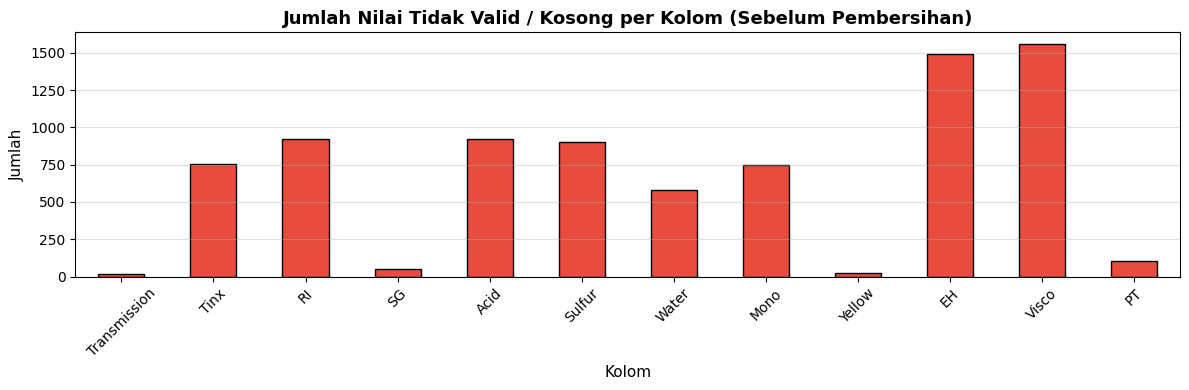


Jumlah nilai tidak valid per kolom:
Transmission      17
Tinx             752
RI               923
SG                50
Acid             919
Sulfur           899
Water            583
Mono             747
Yellow            27
EH              1493
Visco           1559
PT               104
dtype: int64


In [10]:
# Visualisasi missing value (sebelum pembersihan)
missing_before = pd.to_numeric(df_raw[PARAM_COLS].apply(
    lambda col: col.apply(lambda x: pd.isna(x) or str(x).strip() in ['-', ''])
).sum(), errors='coerce')

fig, ax = plt.subplots(figsize=(12, 4))
missing_before.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Jumlah Nilai Tidak Valid / Kosong per Kolom (Sebelum Pembersihan)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kolom', fontsize=11)
ax.set_ylabel('Jumlah', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('missing_sebelum_pembersihan.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nJumlah nilai tidak valid per kolom:")
print(missing_before)

In [11]:
df = df_raw.copy()

# Ganti tanda '-' dan string kosong dengan NaN di kolom numerik
for col in PARAM_COLS:
    df[col] = df[col].apply(lambda x: np.nan if str(x).strip() in ['-', '', 'nan'] else x)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Cek missing value setelah konversi
missing_after_clean = df[PARAM_COLS].isnull().sum()
print("Missing values setelah pembersihan:")
print(missing_after_clean)
print(f"\nTotal missing: {missing_after_clean.sum()}")

Missing values setelah pembersihan:
Transmission      22
Tinx             752
RI               923
SG                54
Acid             919
Sulfur           899
Water            583
Mono             749
Yellow            31
EH              1493
Visco           1560
PT               105
dtype: int64

Total missing: 8090


In [14]:
print("Nilai unik Appreance sebelum encoding:")
print(df[CAT_COL].value_counts())
print()

# Encode: 'clear' (case-insensitive) → 1, lainnya → 0
df['APE_encoded'] = df[CAT_COL].apply(
    lambda x: 1 if str(x).strip().lower() == 'clear' else 0
)

print("Distribusi Appreance setelah encoding:")
print(df['APE_encoded'].value_counts().rename({1: 'Clear (1)', 0: 'Not Clear (0)'}))
print()
print(f"Total Clear (1)     : {(df['APE_encoded'] == 1).sum()}")
print(f"Total Not Clear (0) : {(df['APE_encoded'] == 0).sum()}")

Nilai unik Appreance sebelum encoding:
APE
Clear       1451
clear        210
CLEAR         79
Bergaram       2
cLEAR          2
Cloudy         2
GARAM          1
5              1
yelow          1
Name: count, dtype: int64

Distribusi Appreance setelah encoding:
APE_encoded
Clear (1)        1742
Not Clear (0)      38
Name: count, dtype: int64

Total Clear (1)     : 1742
Total Not Clear (0) : 38


In [15]:
# Semua fitur yang digunakan: numerik + APE encoded
FEATURE_COLS = PARAM_COLS + ['APE_encoded']

print(f"Fitur yang digunakan ({len(FEATURE_COLS)} fitur):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

print(f"\nMissing sebelum imputation:")
print(df[FEATURE_COLS].isnull().sum())

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df[FEATURE_COLS] = imputer.fit_transform(df[FEATURE_COLS])

# Pastikan APE_encoded tetap 0 atau 1 setelah imputation
df['APE_encoded'] = df['APE_encoded'].round().astype(int).clip(0, 1)

print(f"\nMissing setelah KNN Imputation:")
print(df[FEATURE_COLS].isnull().sum())
print("\nKNN Imputation selesai!")

Fitur yang digunakan (13 fitur):
   1. Transmission
   2. Tinx
   3. RI
   4. SG
   5. Acid
   6. Sulfur
   7. Water
   8. Mono
   9. Yellow
  10. EH
  11. Visco
  12. PT
  13. APE_encoded

Missing sebelum imputation:
Transmission      22
Tinx             752
RI               923
SG                54
Acid             919
Sulfur           899
Water            583
Mono             749
Yellow            31
EH              1493
Visco           1560
PT               105
APE_encoded        0
dtype: int64

Missing setelah KNN Imputation:
Transmission    0
Tinx            0
RI              0
SG              0
Acid            0
Sulfur          0
Water           0
Mono            0
Yellow          0
EH              0
Visco           0
PT              0
APE_encoded     0
dtype: int64

KNN Imputation selesai!


In [16]:
# Statistik deskriptif setelah imputation
print("Statistik Deskriptif setelah Imputation:")
df[FEATURE_COLS].describe().round(4)

Statistik Deskriptif setelah Imputation:


,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT,APE_encoded
count,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000,1780.0000
mean,99.6639,19.0972,1.5081,1.1719,0.2370,11.9702,3.5044,22.0193,7.8299,0.0002,53.7445,6.8491,0.9787
std,21.1888,0.1794,0.0012,0.0098,0.3601,0.5183,0.2112,3.6964,0.2402,0.0004,2.4236,2.5884,0.1446
min,91.0840,15.3370,1.4838,1.0750,0.0192,0.2020,0.2030,0.0000,3.4900,0.0000,41.0000,2.0000,0.0000
25%,99.1160,19.0730,1.5078,1.1695,0.2006,11.9700,3.4780,21.4800,7.7000,0.0001,52.4600,5.0000,1.0000
50%,99.2020,19.0990,1.5082,1.1718,0.2030,12.0019,3.4800,22.0180,7.7900,0.0001,53.7800,5.0000,1.0000
75%,99.2580,19.1276,1.5085,1.1743,0.2102,12.0370,3.4840,22.5215,7.9025,0.0002,55.1600,10.0000,1.0000
max,993.0000,20.3126,1.5108,1.5087,11.9960,19.7000,7.9200,95.4900,12.0270,0.0098,73.5000,30.0000,1.0000


In [17]:
# Definisi threshold spesifikasi produk
THRESHOLDS = {
    'Transmission' : ('gt',  98.0),          # Transmission > 98
    'APE_encoded'  : ('eq',  1),             # APE harus Clear
    'Tinx'         : ('range', 18.8, 19.2),  # 18.8 - 19.2
    'RI'           : ('range', 1.507, 1.511),
    'SG'           : ('range', 1.160, 1.180),
    'Acid'         : ('lte',  3.0),          # <= 3.0
    'Sulfur'       : ('range', 11.5, 12.5),
    'Water'        : ('lt',   3.5),          # < 3.5
    'Mono'         : ('range', 19.5, 28.5),
    'Yellow'       : ('lt',   9.0),
    'EH'           : ('lt',   0.7),
    'Visco'        : ('range', 40.0, 80.0),
    'PT'           : ('lte',  30.0),
}

def check_row_passed(row):
    """
    Mengecek satu baris data.
    Return 'Passed' jika SEMUA parameter memenuhi spesifikasi,
    Return 'Not Passed' jika ada satu saja yang gagal.
    """
    for param, spec in THRESHOLDS.items():
        val = row[param]
        if pd.isna(val):
            return 'Not Passed'
        kind = spec[0]
        if kind == 'gt':
            if not (val > spec[1]):
                return 'Not Passed'
        elif kind == 'gte':
            if not (val >= spec[1]):
                return 'Not Passed'
        elif kind == 'lt':
            if not (val < spec[1]):
                return 'Not Passed'
        elif kind == 'lte':
            if not (val <= spec[1]):
                return 'Not Passed'
        elif kind == 'eq':
            if val != spec[1]:
                return 'Not Passed'
        elif kind == 'range':
            if not (spec[1] <= val <= spec[2]):
                return 'Not Passed'
    return 'Passed'

# Langkah 1: cek per baris
df['Row_Status'] = df.apply(check_row_passed, axis=1)

print("=" * 60)
print("HASIL PENGECEKAN PER BARIS")
print("=" * 60)
print(df['Row_Status'].value_counts())
print(f"\nPersentase Passed  : {(df['Row_Status'] == 'Passed').mean()*100:.2f}%")
print(f"Persentase Not Passed: {(df['Row_Status'] == 'Not Passed').mean()*100:.2f}%")

HASIL PENGECEKAN PER BARIS
Row_Status
Passed        1490
Not Passed     290
Name: count, dtype: int64

Persentase Passed  : 83.71%
Persentase Not Passed: 16.29%


In [18]:
# Analisis parameter yang paling banyak menyebabkan Not Passed
print("=" * 70)
print("ANALISIS PARAMETER PENYEBAB NOT PASSED")
print("=" * 70)

fail_count = {}
for param, spec in THRESHOLDS.items():
    kind = spec[0]
    if kind == 'gt':
        n_fail = (df[param] <= spec[1]).sum()
    elif kind == 'gte':
        n_fail = (df[param] < spec[1]).sum()
    elif kind == 'lt':
        n_fail = (df[param] >= spec[1]).sum()
    elif kind == 'lte':
        n_fail = (df[param] > spec[1]).sum()
    elif kind == 'eq':
        n_fail = (df[param] != spec[1]).sum()
    elif kind == 'range':
        n_fail = ((df[param] < spec[1]) | (df[param] > spec[2])).sum()
    fail_count[param] = n_fail
    
fail_series = pd.Series(fail_count).sort_values(ascending=False)
for param, n in fail_series.items():
    spec = THRESHOLDS[param]
    if spec[0] == 'range':
        spec_str = f"[{spec[1]}, {spec[2]}]"
    elif spec[0] == 'gt':
        spec_str = f"> {spec[1]}"
    elif spec[0] == 'lt':
        spec_str = f"< {spec[1]}"
    elif spec[0] == 'lte':
        spec_str = f"<= {spec[1]}"
    elif spec[0] == 'eq':
        spec_str = f"== {spec[1]}"
    else:
        spec_str = str(spec[1:])
    pct = n / len(df) * 100
    print(f"  {param:15s} (Spec: {spec_str:15s}): {n:4d} baris gagal ({pct:.2f}%)")

ANALISIS PARAMETER PENYEBAB NOT PASSED
  Tinx            (Spec: [18.8, 19.2]   ):   92 baris gagal (5.17%)
  Water           (Spec: < 3.5          ):   80 baris gagal (4.49%)
  Mono            (Spec: [19.5, 28.5]   ):   76 baris gagal (4.27%)
  Sulfur          (Spec: [11.5, 12.5]   ):   54 baris gagal (3.03%)
  SG              (Spec: [1.16, 1.18]   ):   47 baris gagal (2.64%)
  RI              (Spec: [1.507, 1.511] ):   47 baris gagal (2.64%)
  APE_encoded     (Spec: == 1           ):   38 baris gagal (2.13%)
  Transmission    (Spec: > 98.0         ):   13 baris gagal (0.73%)
  Yellow          (Spec: < 9.0          ):    4 baris gagal (0.22%)
  Acid            (Spec: <= 3.0         ):    2 baris gagal (0.11%)
  EH              (Spec: < 0.7          ):    0 baris gagal (0.00%)
  Visco           (Spec: [40.0, 80.0]   ):    0 baris gagal (0.00%)
  PT              (Spec: <= 30.0        ):    0 baris gagal (0.00%)


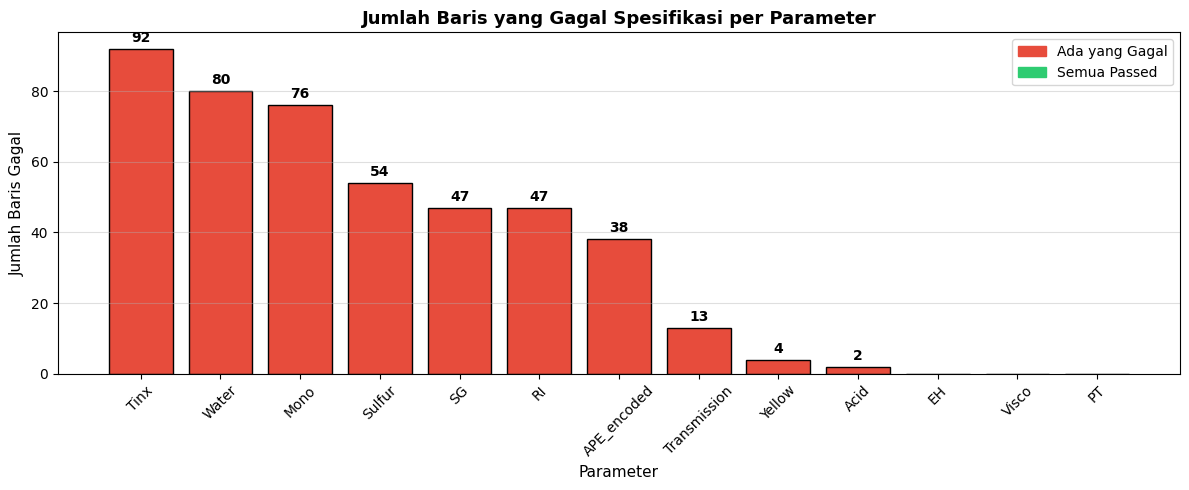

Grafik disimpan: parameter_gagal.png


In [19]:
# Visualisasi jumlah baris gagal per parameter
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in fail_series.values]
bars = ax.bar(fail_series.index, fail_series.values, color=colors, edgecolor='black')
for bar, val in zip(bars, fail_series.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Jumlah Baris yang Gagal Spesifikasi per Parameter', fontsize=13, fontweight='bold')
ax.set_xlabel('Parameter', fontsize=11)
ax.set_ylabel('Jumlah Baris Gagal', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
red_patch   = mpatches.Patch(color='#e74c3c', label='Ada yang Gagal')
green_patch = mpatches.Patch(color='#2ecc71', label='Semua Passed')
ax.legend(handles=[red_patch, green_patch], fontsize=10)
plt.tight_layout()
plt.savefig('parameter_gagal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: parameter_gagal.png")

In [20]:
# Langkah 2: labeling per batch
# Batch dinyatakan TIDAK LAYAK jika ada SATU saja baris 'Not Passed'
batch_label = (
    df.groupby('Batch')['Row_Status']
    .apply(lambda s: 1 if (s == 'Passed').all() else 0)
    .rename('Label_Batch')
)

# Map label batch ke setiap baris
df = df.merge(batch_label, on='Batch', how='left')

print("=" * 60)
print("HASIL LABELING PER BATCH")
print("=" * 60)
print(f"Total batch    : {df['Batch'].nunique()}")
print(f"Batch Layak    : {batch_label.sum()}  ({batch_label.mean()*100:.2f}%)")
print(f"Batch Tdk Layak: {(batch_label == 0).sum()}  ({(batch_label == 0).mean()*100:.2f}%)")
print()
print("Distribusi Label pada baris data:")
print(df['Label_Batch'].value_counts().rename({1: 'Layak (1)', 0: 'Tidak Layak (0)'}))

HASIL LABELING PER BATCH
Total batch    : 975
Batch Layak    : 704  (72.21%)
Batch Tdk Layak: 271  (27.79%)

Distribusi Label pada baris data:
Label_Batch
Layak (1)          1300
Tidak Layak (0)     480
Name: count, dtype: int64


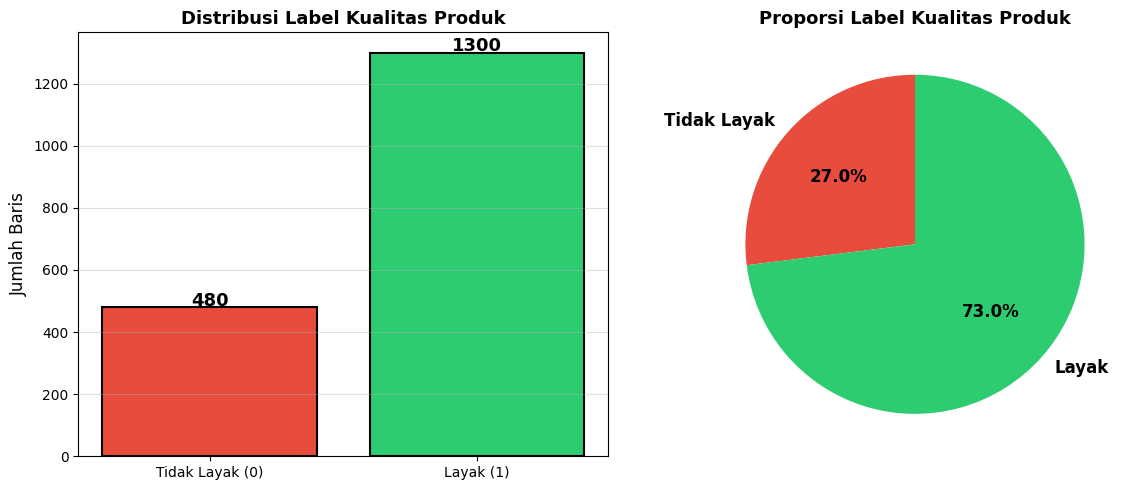

Grafik disimpan: distribusi_label.png


In [21]:
# Visualisasi distribusi label
label_counts = df['Label_Batch'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
clrs = ['#e74c3c', '#2ecc71']
lbls = ['Tidak Layak (0)', 'Layak (1)']
bars = axes[0].bar(lbls, label_counts.values, color=clrs, edgecolor='black', linewidth=1.5)
for bar, v in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Baris', fontsize=12)
axes[0].set_title('Distribusi Label Kualitas Produk', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

# Pie chart
axes[1].pie(label_counts.values,
            labels=['Tidak Layak', 'Layak'],
            autopct='%1.1f%%',
            colors=clrs,
            startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Label Kualitas Produk', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: distribusi_label.png")

In [22]:
# Simpan data berlabel untuk referensi
df_labeled = df[['ID', 'Batch', 'Tanggal'] + FEATURE_COLS + ['Row_Status', 'Label_Batch']].copy()
df_labeled.to_excel('Data_Labeled_Hasil_1.xlsx', index=False)
print("Data berlabel disimpan: Data_Labeled_Hasil_1.xlsx")
df_labeled.head(10)

Data berlabel disimpan: Data_Labeled_Hasil_1.xlsx


,ID,Batch,Tanggal,Transmission,Tinx,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT,APE_encoded,Row_Status,Label_Batch
0,11,TG2024L28,2025-05-07,99.275,19.07866,1.508670,1.17230,0.2030,12.0810,3.480,22.384,7.84,0.00010,47.20,10.0,1,Passed,1
1,12,TG2025A07,2025-05-07,99.229,19.13652,1.508820,1.17380,0.2540,11.9260,3.480,22.082,7.90,0.00050,45.07,10.0,1,Passed,1
2,13,TG2025B07-1,2025-05-07,99.286,19.11352,1.509300,1.17405,0.2010,11.8490,3.480,21.758,7.79,0.00010,49.40,10.0,1,Passed,1
3,38,TG02025E05,2025-05-09,99.216,19.11054,1.508490,1.16940,0.2540,12.0990,3.490,21.852,7.85,0.00014,49.60,10.0,1,Passed,1
4,39,TG02025E06,2025-05-09,99.308,19.08874,1.508820,1.17240,0.2500,12.1760,3.490,21.970,7.82,0.00014,47.20,10.0,1,Passed,1
5,81,TG2025E063,2025-05-16,99.201,19.07896,1.509520,1.17925,0.2028,11.9870,3.484,22.446,7.64,0.00012,52.94,6.0,1,Passed,1
6,90,TG2025E062,2025-05-17,99.178,19.10658,1.504850,1.17472,0.2010,12.0890,3.484,22.032,7.60,0.00018,53.64,10.0,1,Not Passed,0
7,92,TG2025E062,2025-05-17,99.215,19.10494,1.508846,1.17162,0.2102,12.0108,3.480,21.954,7.79,0.00016,54.08,10.0,1,Passed,0
8,93,TG2025E063,2025-05-17,99.220,19.11282,1.507970,1.17575,0.2062,11.9870,3.480,21.800,7.73,0.00014,55.70,10.0,1,Passed,1
9,95,TG2025E064,2025-05-17,99.171,19.11540,1.509930,1.18156,0.2000,12.0090,3.482,21.740,7.84,0.00010,51.66,6.0,1,Not Passed,0


In [23]:
X = df[FEATURE_COLS].copy()
y = df['Label_Batch'].copy()

print(f"Fitur (X) : {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nDistribusi y: {y.value_counts().to_dict()}")

# Cek apakah kedua kelas ada
assert y.nunique() >= 2, (
    "PERINGATAN: Data hanya memiliki 1 kelas! "
    "Periksa kembali threshold spesifikasi."
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("SPLIT DATA BERHASIL!")
print("=" * 60)
print(f"Data Training  : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Distribusi   : {y_train.value_counts().to_dict()}")
print(f"Data Validasi  : {X_val.shape[0]} baris ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Distribusi   : {y_val.value_counts().to_dict()}")
print("=" * 60)

Fitur (X) : (1780, 13)
Target (y): (1780,)

Distribusi y: {1: 1300, 0: 480}

SPLIT DATA BERHASIL!
Data Training  : 1424 baris (80.0%)
  Distribusi   : {1: 1040, 0: 384}
Data Validasi  : 356 baris (20.0%)
  Distribusi   : {1: 260, 0: 96}


In [25]:
# Inisialisasi model XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("Model XGBoost berhasil diinisialisasi!")
print(f"\nHyperparameters:")
print(f"  n_estimators      : {model.n_estimators}")
print(f"  max_depth         : {model.max_depth}")
print(f"  learning_rate     : {model.learning_rate}")
print(f"  subsample         : {model.subsample}")
print(f"  colsample_bytree  : {model.colsample_bytree}")
print(f"  gamma             : {model.gamma}")
print(f"  min_child_weight  : {model.min_child_weight}")

Model XGBoost berhasil diinisialisasi!

Hyperparameters:
  n_estimators      : 200
  max_depth         : 5
  learning_rate     : 0.05
  subsample         : 0.8
  colsample_bytree  : 0.8
  gamma             : 1
  min_child_weight  : 3


In [26]:
print("Melatih model pada seluruh data training...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print("Training selesai!")

Melatih model pada seluruh data training...
Training selesai!
